## Part 1: Exploratory Data Analysis (EDA) & Cleaning

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('anomaly.csv')
df

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0


In [4]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

In [6]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [7]:
print("--- Missing Values ---")
print(df.isnull().sum())

--- Missing Values ---
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64


In [8]:
# 2. Identify skewed distributions
numerical_features = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
skewness = df[numerical_features].skew()
print("\n--- Skewness Values ---")
print(skewness)


--- Skewness Values ---
Air temperature [K]        0.114274
Process temperature [K]    0.015027
Rotational speed [rpm]     1.993171
Torque [Nm]               -0.009517
Tool wear [min]            0.027292
dtype: float64


In [9]:
# 3. Correlation Matrix (Numerical vs Target)
correlation = df[numerical_features + ['Machine failure']].corr()
print("\n--- Correlations with Machine Failure ---")
print(correlation['Machine failure'].sort_values(ascending=False))


--- Correlations with Machine Failure ---
Machine failure            1.000000
Torque [Nm]                0.191321
Tool wear [min]            0.105448
Air temperature [K]        0.082556
Process temperature [K]    0.035946
Rotational speed [rpm]    -0.044188
Name: Machine failure, dtype: float64


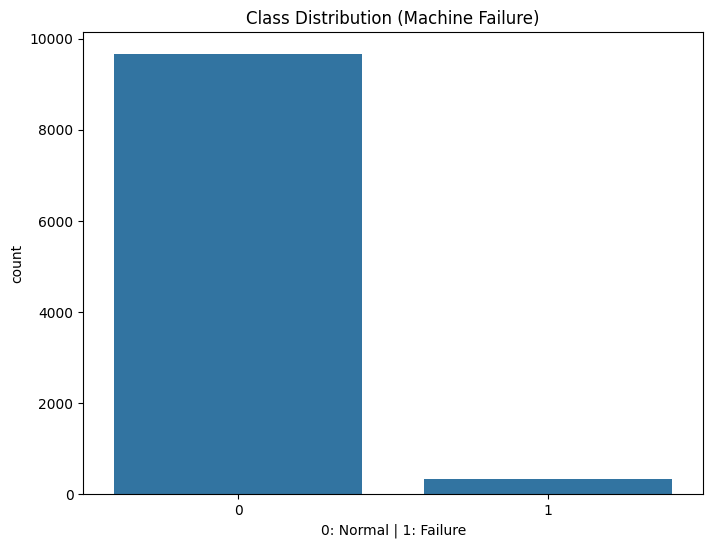

In [10]:
# Class Distribution Plot
fig, ax = plt.subplots(figsize=(8, 6))
sns.countplot(x='Machine failure', data=df, ax=ax)
ax.set_title("Class Distribution (Machine Failure)")
ax.set_xlabel("0: Normal | 1: Failure")
plt.savefig('class_distribution.png')

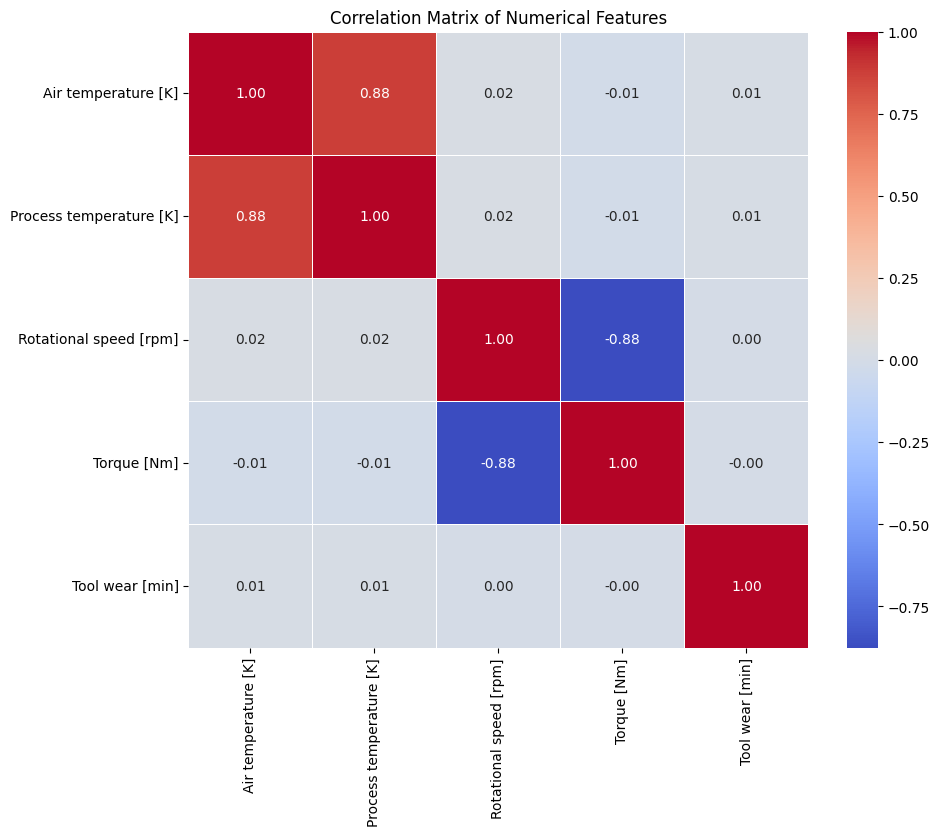

In [11]:
numerical_cols = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

plt.figure(figsize=(10, 8))
correlation_matrix = df[numerical_cols].corr()

sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Numerical Features")
plt.show()

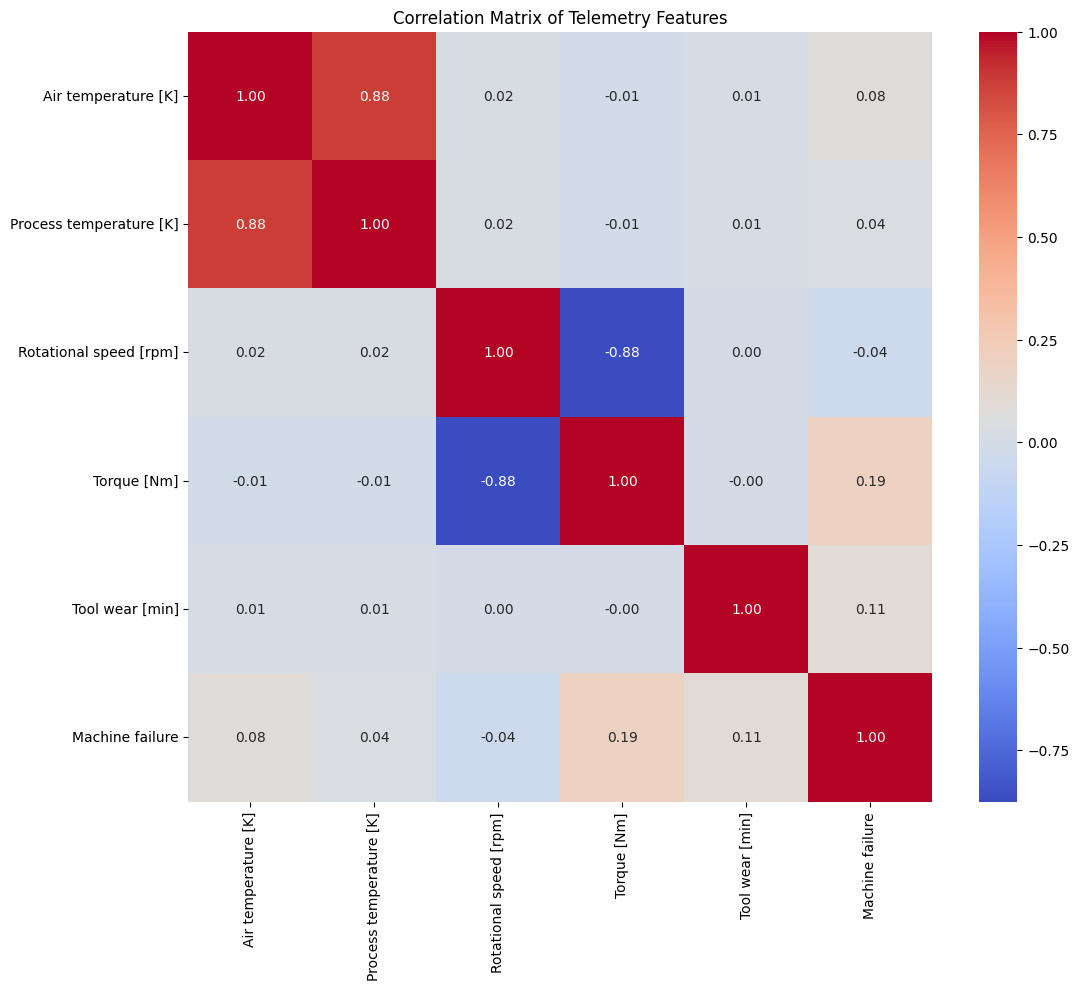

In [12]:
# Correlation Matrix Heatmap
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(df[numerical_features + ['Machine failure']].corr(), annot=True, cmap="coolwarm", fmt=".2f", ax=ax)
ax.set_title("Correlation Matrix of Telemetry Features")
plt.savefig('correlation_matrix.png')

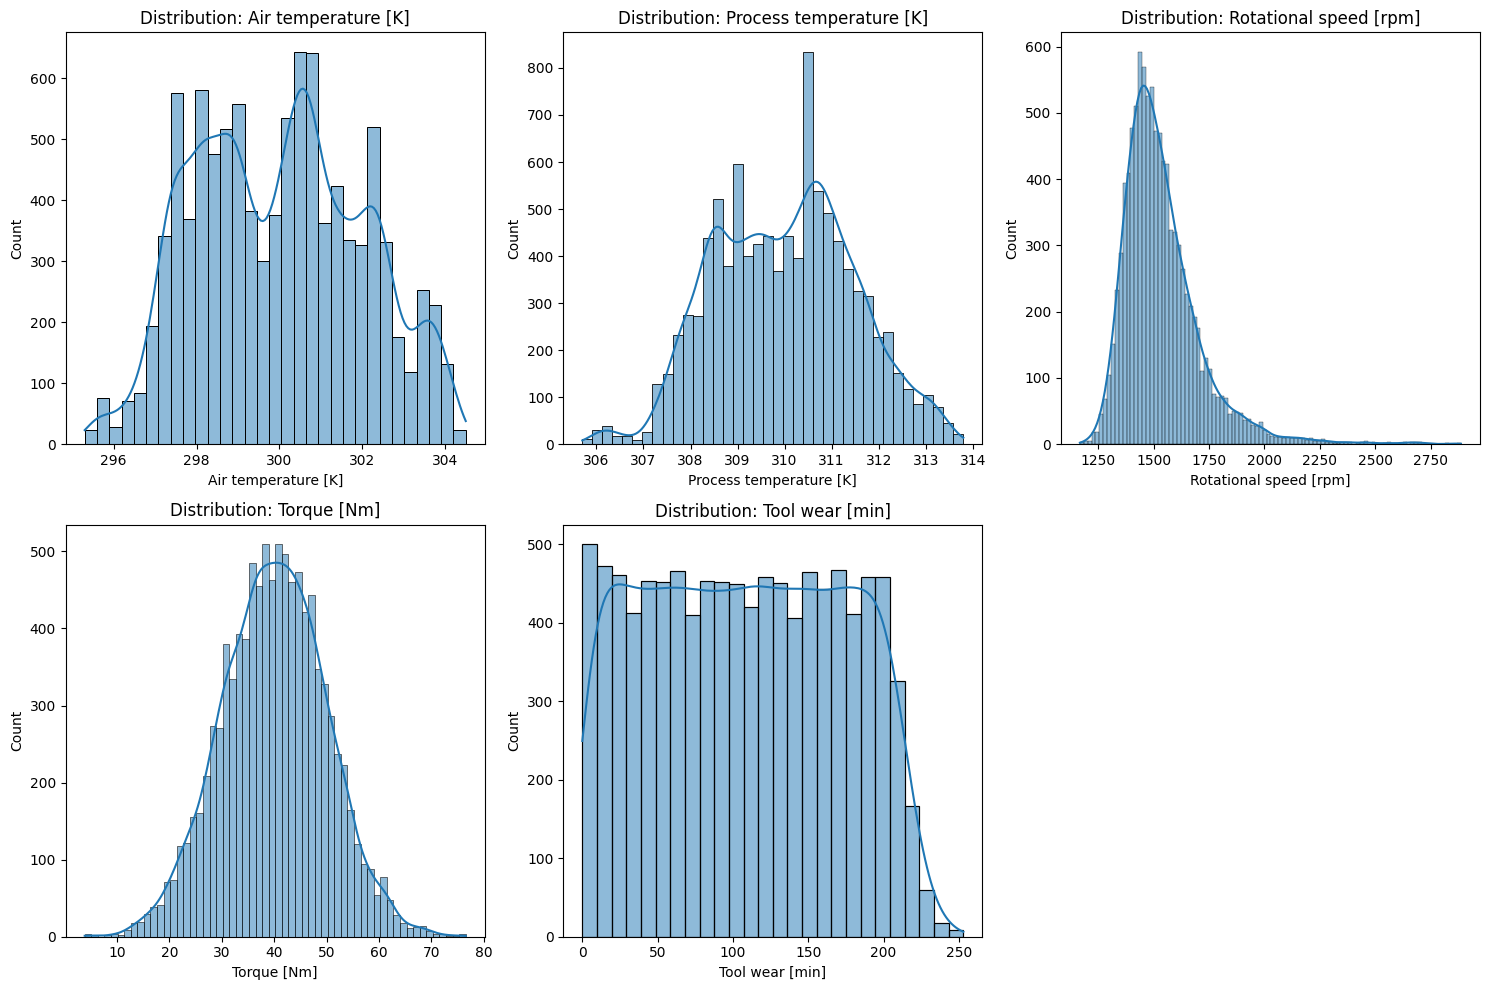

In [13]:
# Feature Distributions
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
for i, col in enumerate(numerical_features):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution: {col}')
fig.delaxes(axes[-1])
plt.tight_layout()
plt.savefig('feature_distributions.png')

## Part 2: Modeling & Hyperparameter Tuning

In [14]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor
from sklearn.covariance import EllipticEnvelope
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import ParameterGrid

In [15]:
labels_to_hide = ['Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']
ground_truth = df['Machine failure'].copy()
X = df.drop(columns=['UDI', 'Product ID'] + labels_to_hide)

In [16]:
# Scaling Numerical Features
scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X[numerical_cols])

In [17]:
# Categorical Handling: OneHotEncoder 
ohe = OneHotEncoder(sparse_output=False)
X_type_encoded = ohe.fit_transform(X[['Type']])

In [18]:
X_final = np.hstack([X_num_scaled, X_type_encoded])

In [19]:
# 1. Defining the Business Cost Scorer
def evaluate_business_cost(y_true, y_pred):
    y_pred_mapped = np.where(y_pred == -1, 1, 0)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred_mapped).ravel()
    return (fp * 500) + (fn * 15000)

In [20]:
contamination_range = [0.03, 0.035, 0.04, 0.05]

model_configs = {
    "Isolation Forest": {
        "class": IsolationForest,
        "params": {
            "contamination": contamination_range,
            "n_estimators": [100, 200],
            "random_state": [42]
        }
    },
    "One-Class SVM": {
        "class": OneClassSVM,
        "params": {
            "nu": [0.03, 0.05], 
            "kernel": ["rbf"], 
            "gamma": ["scale"]
        }
    },
    "Local Outlier Factor": {
        "class": LocalOutlierFactor,
        "params": {
            "contamination": contamination_range,
            "n_neighbors": [20, 30]
        }
    },
    "Elliptic Envelope": {
        "class": EllipticEnvelope,
        "params": {
            "contamination": contamination_range,
            "random_state": [42]
        }
    }
}

In [21]:
best_results = {}
preds_dict = {} 

for model_name, config in model_configs.items():
    print(f"Tuning {model_name}...")
    best_score = float('inf')
    best_params = None
    best_preds = None 
    
    for p in ParameterGrid(config["params"]):
        model = config["class"](**p)
        
        if model_name == "Local Outlier Factor":
            preds = model.fit_predict(X_final)
        else:
            model.fit(X_final)
            preds = model.predict(X_final)
            
        cost = evaluate_business_cost(ground_truth, preds)
        
        if cost < best_score:
            best_score = cost
            best_params = p
            best_preds = preds 
            
    best_results[model_name] = {"params": best_params, "cost": best_score}
    preds_dict[model_name] = best_preds 

print("\n" + "="*30)
print("GRID SEARCH RESULTS")
print("="*30)
for model, results in best_results.items():
    print(f"{model}:")
    print(f"  - Best Params: {results['params']}")
    print(f"  - Minimum Cost: €{results['cost']:,}")
    print("-" * 30)

Tuning Isolation Forest...
Tuning One-Class SVM...
Tuning Local Outlier Factor...
Tuning Elliptic Envelope...


/Users/colenegeoffroy/Documents/B2/S2/Unsupervised model/creditcardvenv/lib/python3.11/site-packages/sklearn/covariance/_robust_covariance.py:188: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-45.074812981815008 > -45.819035260608636). You may want to try with a higher value of support_fraction (current value: 0.501).
  warnings.warn(
/Users/colenegeoffroy/Documents/B2/S2/Unsupervised model/creditcardvenv/lib/python3.11/site-packages/sklearn/covariance/_robust_covariance.py:188: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-45.074812981815008 > -45.819035260608636). You may want to try with a higher value of support_fraction (current value: 0.501).
  warnings.warn(
/Users/colenegeoffroy/Documents/B2/S2/Unsupervised model/creditcardvenv/lib/python3.11/site-packages/sklearn/covariance/_robust_covariance.py:188: RuntimeWarning: Determinant has increased; this should not happen: log(det)


GRID SEARCH RESULTS
Isolation Forest:
  - Best Params: {'contamination': 0.03, 'n_estimators': 200, 'random_state': 42}
  - Minimum Cost: €4,444,500
------------------------------
One-Class SVM:
  - Best Params: {'gamma': 'scale', 'kernel': 'rbf', 'nu': 0.05}
  - Minimum Cost: €3,631,500
------------------------------
Local Outlier Factor:
  - Best Params: {'contamination': 0.05, 'n_neighbors': 30}
  - Minimum Cost: €3,676,500
------------------------------
Elliptic Envelope:
  - Best Params: {'contamination': 0.05, 'random_state': 42}
  - Minimum Cost: €3,692,000
------------------------------


## Part 3: Technical Comparison & Visualizations

In [22]:
from sklearn.decomposition import PCA
from sklearn.neighbors import LocalOutlierFactor

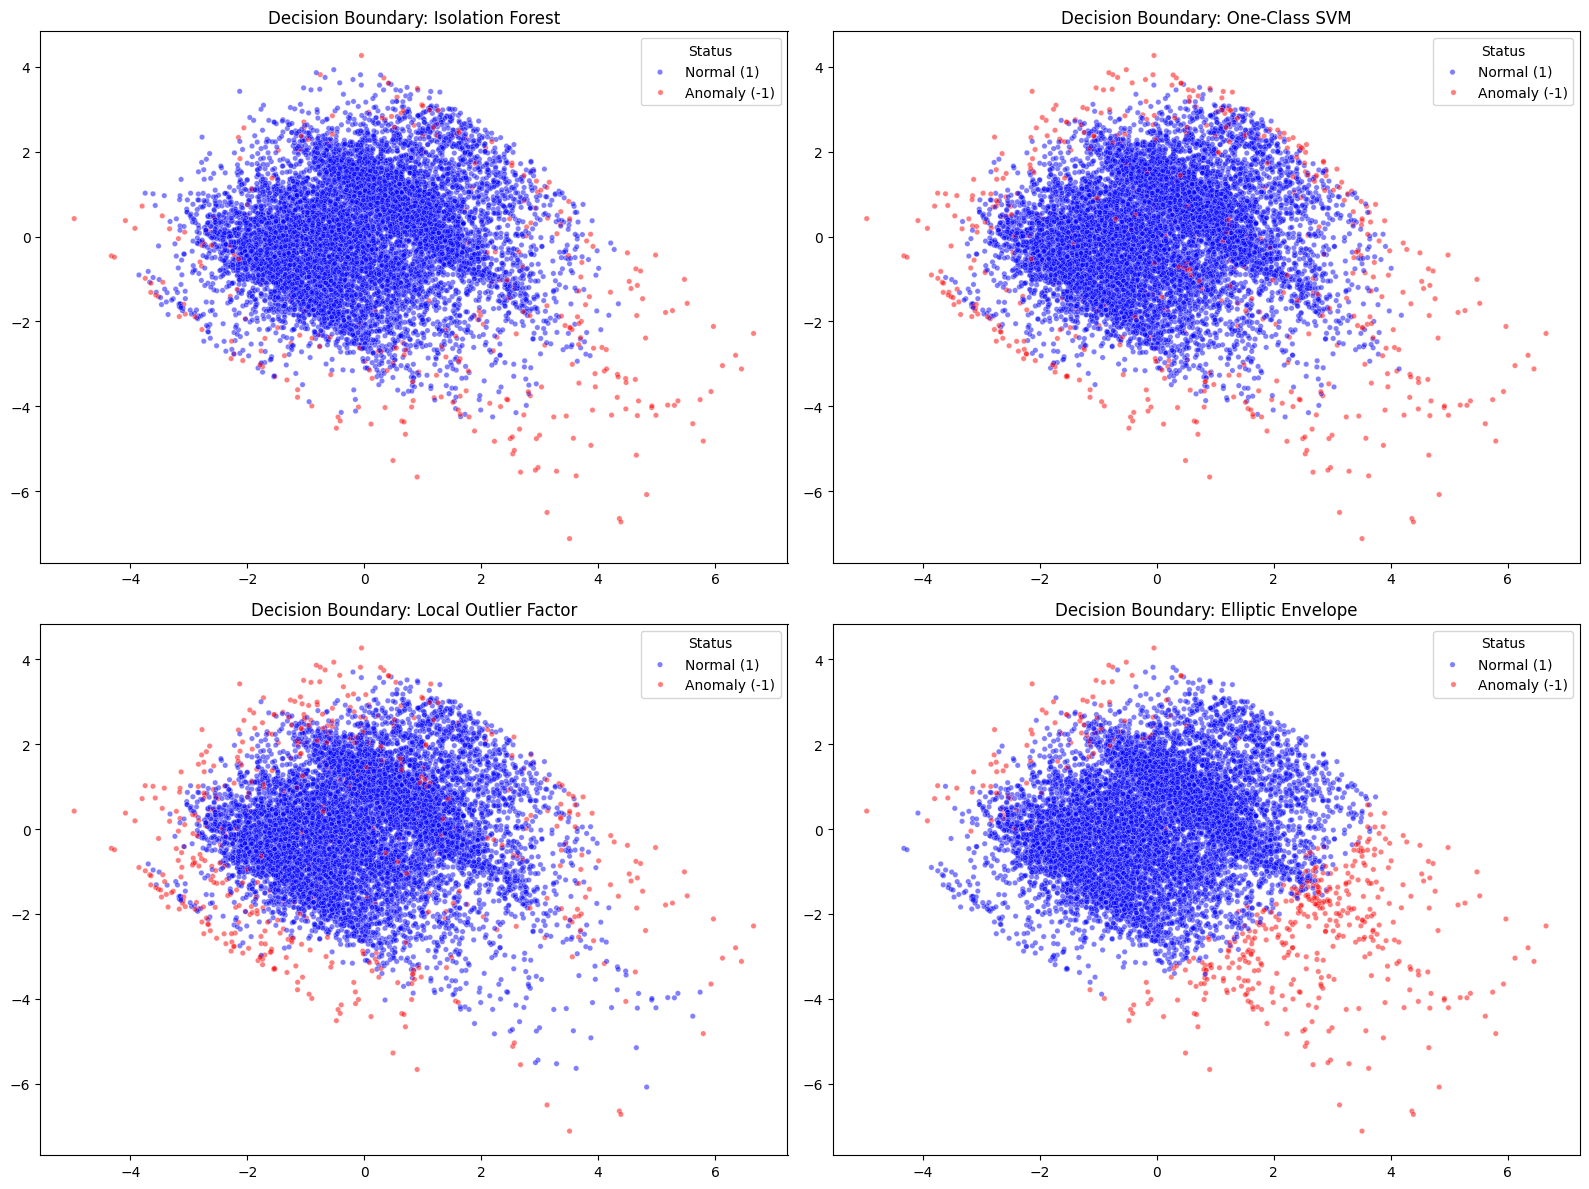

In [23]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_final)

plt.figure(figsize=(16, 12))
for i, name in enumerate(preds_dict.keys()):
    plt.subplot(2, 2, i+1)
    # Map predictions: 1 = Normal (Blue), -1 = Anomaly (Red)
    sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=preds_dict[name], 
                    palette={1: 'blue', -1: 'red'}, s=15, alpha=0.5)
    plt.title(f"Decision Boundary: {name}")
    plt.legend(title='Status', labels=['Normal (1)', 'Anomaly (-1)'])

plt.tight_layout()
plt.show()

## Part 4: Managerial Conclusion & Actionable Strategy

In [24]:
# Business Cost Matrix
COST_FP = 500
COST_FN = 15000   
results = []
for name, preds in preds_dict.items():
    y_pred_mapped = np.where(preds == -1, 1, 0)
    tn, fp, fn, tp = confusion_matrix(ground_truth, y_pred_mapped).ravel()
    total_cost = (fp * COST_FP) + (fn * COST_FN)
    
    results.append({
        'Model': name,
        'TP (Hits)': tp,
        'FP (False Alarms)': fp,
        'FN (Missed Failures)': fn,
        'Total Business Cost (€)': total_cost
    })

In [25]:
summary_df = pd.DataFrame(results).sort_values('Total Business Cost (€)')
print("\n--- Final Managerial Summary ---")
summary_df


--- Final Managerial Summary ---


,Model,TP (Hits),FP (False Alarms),FN (Missed Failures),Total Business Cost (€)
1,One-Class SVM,110,393,229,3631500
2,Local Outlier Factor,107,393,232,3676500
3,Elliptic Envelope,106,394,233,3692000
0,Isolation Forest,51,249,288,4444500


## Change in contamination and range 

In [33]:
# Créez ces colonnes avant le split/scaling
X['Power'] = df['Torque [Nm]'] * df['Rotational speed [rpm]']  # Puissance mécanique
X['Temp_Diff'] = df['Process temperature [K]'] - df['Air temperature [K]'] # Écart de chauffe
X['Wear_Rate'] = df['Tool wear [min]'] * df['Torque [Nm]'] # Fatigue de l'outil

In [34]:
contamination_range = [0.05, 0.08, 0.10, 0.12, 0.15]

model_configs = {
    "Isolation Forest": {
        "class": IsolationForest,
        "params": {
            "contamination": contamination_range,
            "n_estimators": [200, 500], 
            "max_features": [0.8, 1.0],   
            "bootstrap": [True, False],
            "random_state": [42]
        }
    },
    "One-Class SVM": {
        "class": OneClassSVM,
        "params": {
            "nu": [0.05, 0.10, 0.15],    
            "kernel": ["rbf"],           
            "gamma": [0.01, 0.1, 'scale'] 
        }
    },
    "Local Outlier Factor": {
        "class": LocalOutlierFactor,
        "params": {
            "contamination": contamination_range,
            "n_neighbors": [10, 20, 35], 
            "novelty": [True]           
        }
    },
    "Elliptic Envelope": {
        "class": EllipticEnvelope,
        "params": {
            "contamination": contamination_range,
            "assume_centered": [False, True],
            "support_fraction": [None, 0.85], 
            "random_state": [42]
        }
    }
}

In [35]:
best_results = {}
preds_dict = {} 

for model_name, config in model_configs.items():
    print(f"Tuning {model_name}...")
    best_score = float('inf')
    best_params = None
    best_preds = None 
    
    for p in ParameterGrid(config["params"]):
        model = config["class"](**p)
    
    if model_name == "Local Outlier Factor":
        # Si novelty est True, on utilise fit puis predict
        if p.get("novelty"):
            model.fit(X_final)
            preds = model.predict(X_final)
        else:
            preds = model.fit_predict(X_final)
    else:
        # Pour les autres modèles (Isolation Forest, SVM, etc.)
        model.fit(X_final)
        preds = model.predict(X_final)
        
    cost = evaluate_business_cost(ground_truth, preds)
        
    if cost < best_score:
        best_score = cost
        best_params = p
        best_preds = preds 
            
    best_results[model_name] = {"params": best_params, "cost": best_score}
    preds_dict[model_name] = best_preds 

print("\n" + "="*30)
print("GRID SEARCH RESULTS")
print("="*30)
for model, results in best_results.items():
    print(f"{model}:")
    print(f"  - Best Params: {results['params']}")
    print(f"  - Minimum Cost: €{results['cost']:,}")
    print("-" * 30)

Tuning Isolation Forest...
Tuning One-Class SVM...
Tuning Local Outlier Factor...
Tuning Elliptic Envelope...

GRID SEARCH RESULTS
Isolation Forest:
  - Best Params: {'bootstrap': False, 'contamination': 0.15, 'max_features': 1.0, 'n_estimators': 500, 'random_state': 42}
  - Minimum Cost: €4,207,500
------------------------------
One-Class SVM:
  - Best Params: {'gamma': 'scale', 'kernel': 'rbf', 'nu': 0.15}
  - Minimum Cost: €2,747,500
------------------------------
Local Outlier Factor:
  - Best Params: {'contamination': 0.15, 'n_neighbors': 35, 'novelty': True}
  - Minimum Cost: €2,812,500
------------------------------
Elliptic Envelope:
  - Best Params: {'assume_centered': True, 'contamination': 0.15, 'random_state': 42, 'support_fraction': 0.85}
  - Minimum Cost: €3,401,500
------------------------------


/Users/colenegeoffroy/Documents/B2/S2/Unsupervised model/creditcardvenv/lib/python3.11/site-packages/sklearn/covariance/_robust_covariance.py:188: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-46.237747945609868 > -47.581194127107864). You may want to try with a higher value of support_fraction (current value: 0.851).
  warnings.warn(
/Users/colenegeoffroy/Documents/B2/S2/Unsupervised model/creditcardvenv/lib/python3.11/site-packages/sklearn/covariance/_robust_covariance.py:188: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-43.381999135391837 > -44.245661273156195). You may want to try with a higher value of support_fraction (current value: 0.851).
  warnings.warn(
/Users/colenegeoffroy/Documents/B2/S2/Unsupervised model/creditcardvenv/lib/python3.11/site-packages/sklearn/covariance/_robust_covariance.py:188: RuntimeWarning: Determinant has increased; this should not happen: log(det)

### Part 3: Technical Comparison & Visualizations

In [36]:
from sklearn.decomposition import PCA
from sklearn.neighbors import LocalOutlierFactor

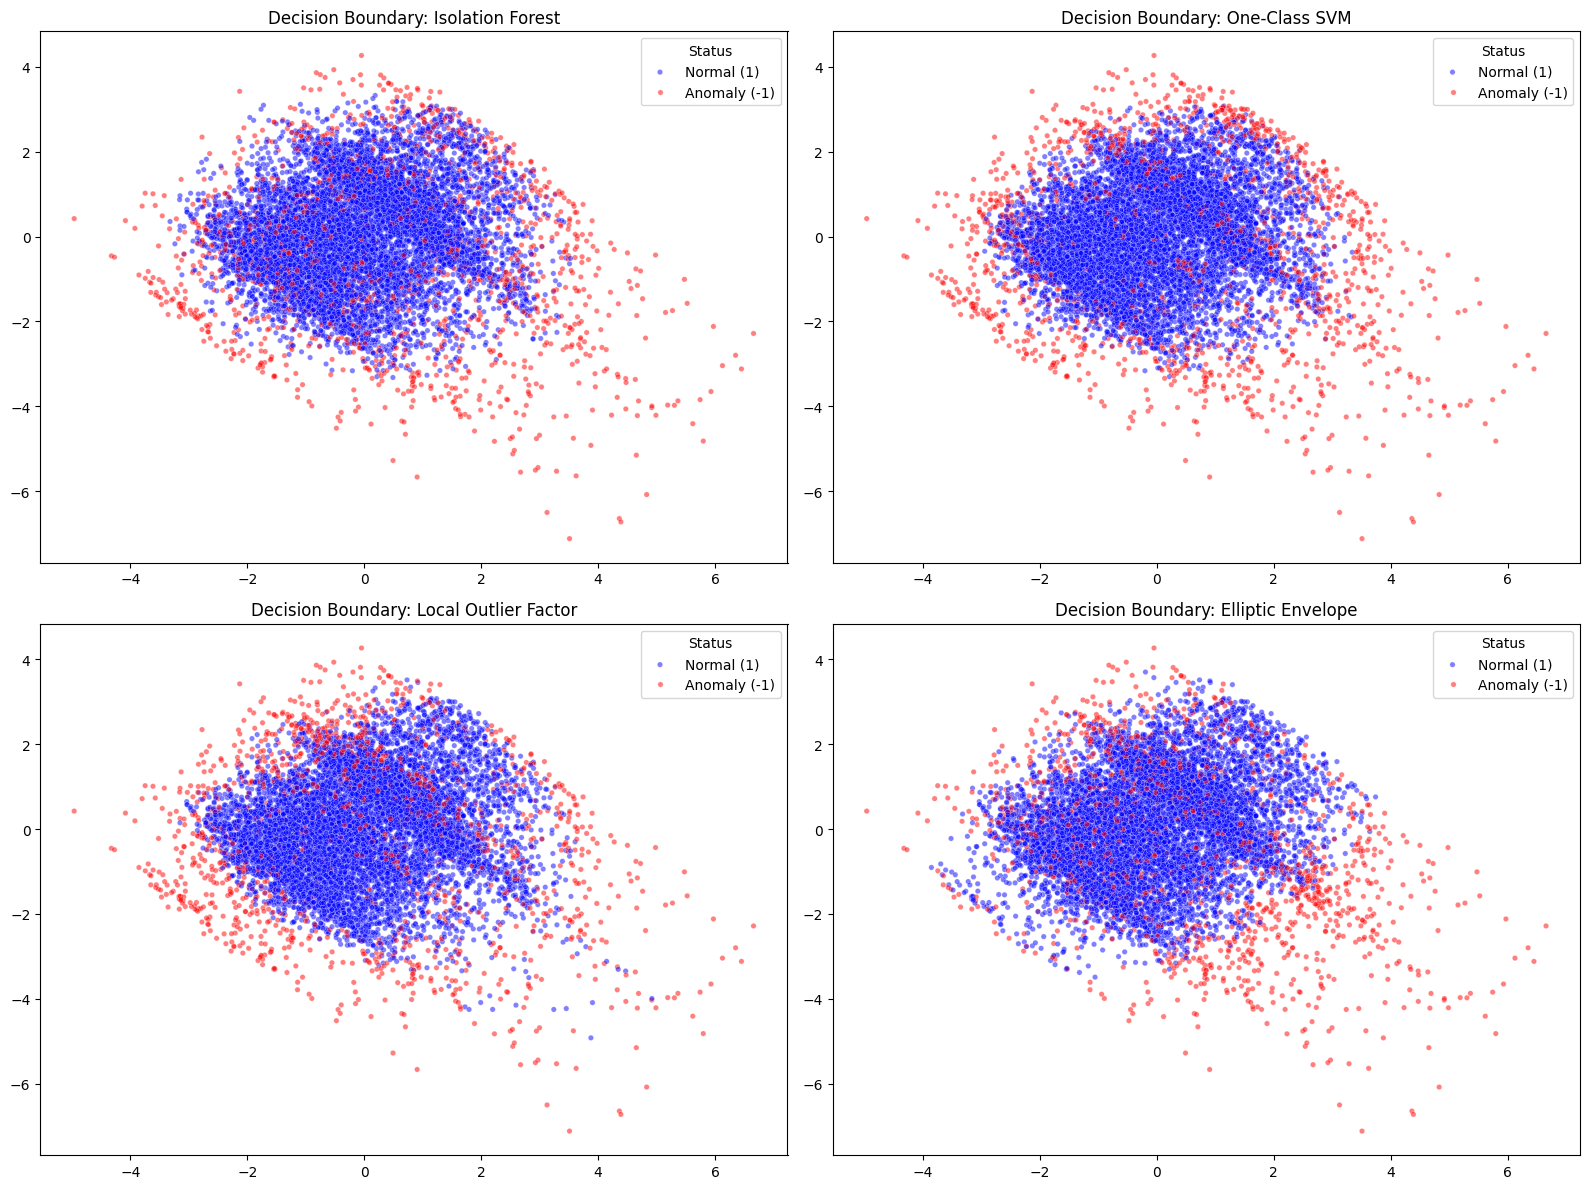

In [37]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_final)

plt.figure(figsize=(16, 12))
for i, name in enumerate(preds_dict.keys()):
    plt.subplot(2, 2, i+1)
    # Map predictions: 1 = Normal (Blue), -1 = Anomaly (Red)
    sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=preds_dict[name], 
                    palette={1: 'blue', -1: 'red'}, s=15, alpha=0.5)
    plt.title(f"Decision Boundary: {name}")
    plt.legend(title='Status', labels=['Normal (1)', 'Anomaly (-1)'])

plt.tight_layout()
plt.show()

### Part 4 : Managerial Conclusion & Actionable Strategy

In [38]:
# Business Cost Matrix
COST_FP = 500
COST_FN = 15000   
results = []
for name, preds in preds_dict.items():
    y_pred_mapped = np.where(preds == -1, 1, 0)
    tn, fp, fn, tp = confusion_matrix(ground_truth, y_pred_mapped).ravel()
    total_cost = (fp * COST_FP) + (fn * COST_FN)
    
    results.append({
        'Model': name,
        'TP (Hits)': tp,
        'FP (False Alarms)': fp,
        'FN (Missed Failures)': fn,
        'Total Business Cost (€)': total_cost
    })

In [39]:
summary_df = pd.DataFrame(results).sort_values('Total Business Cost (€)')
print("\n--- Final Managerial Summary ---")
summary_df


--- Final Managerial Summary ---


,Model,TP (Hits),FP (False Alarms),FN (Missed Failures),Total Business Cost (€)
1,One-Class SVM,199,1295,140,2747500
2,Local Outlier Factor,192,1215,147,2812500
3,Elliptic Envelope,157,1343,182,3401500
0,Isolation Forest,105,1395,234,4207500
